In [1]:
import os
import pandas as pd
from pandas import DataFrame
from pandas import concat
import numpy as np
from numpy import concatenate
from math import sqrt
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [2]:
folder_path='/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Small_Trans.csv'
df = pd.read_csv(folder_path)
print(len(df.index))


5078345


In [3]:
df.head()


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [4]:
print(df.dtypes)


Timestamp              object
From Bank               int64
Account                object
To Bank                 int64
Account.1              object
Amount Received       float64
Receiving Currency     object
Amount Paid           float64
Payment Currency       object
Payment Format         object
Is Laundering           int64
dtype: object


In [5]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Amount Received'] = df['Amount Received'].astype('float32')
df['Amount Paid'] = df['Amount Paid'].astype('float32')
df['Is Laundering'] = df['Is Laundering'].astype('float32')
df.dtypes

Timestamp             datetime64[ns]
From Bank                      int64
Account                       object
To Bank                        int64
Account.1                     object
Amount Received              float32
Receiving Currency            object
Amount Paid                  float32
Payment Currency              object
Payment Format                object
Is Laundering                float32
dtype: object

In [6]:
print(df.isnull().sum())


Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64


In [7]:
not_equal1 = df.loc[~(df['Amount Received'] == df['Amount Paid'])]
not_equal2 = df.loc[~(df['Receiving Currency'] == df['Payment Currency'])]
print(not_equal1)
print(not_equal2)

                  Timestamp  From Bank    Account  To Bank  Account.1  \
1173    2022-09-01 00:22:00       1362  80030A870     1362  80030A870   
7156    2022-09-01 00:28:00      11318  800C51010    11318  800C51010   
7925    2022-09-01 00:12:00        795  800D98770      795  800D98770   
8467    2022-09-01 00:01:00       1047  800E92CF0     1047  800E92CF0   
11529   2022-09-01 00:22:00      11157  80135FFC0    11157  80135FFC0   
...                     ...        ...        ...      ...        ...   
5078167 2022-09-10 23:30:00      23537  803949A90    23537  803949A90   
5078234 2022-09-10 23:59:00      16163  803638A90    16163  803638A90   
5078236 2022-09-10 23:55:00      16163  803638A90    16163  803638A90   
5078316 2022-09-10 23:44:00     215064  808F06E11   215064  808F06E10   
5078318 2022-09-10 23:45:00     215064  808F06E11   215064  808F06E10   

         Amount Received Receiving Currency   Amount Paid Payment Currency  \
1173           52.110001               Euro  

In [8]:
print(sorted(df['Receiving Currency'].unique()))
print(sorted(df['Payment Currency'].unique()))

['Australian Dollar', 'Bitcoin', 'Brazil Real', 'Canadian Dollar', 'Euro', 'Mexican Peso', 'Ruble', 'Rupee', 'Saudi Riyal', 'Shekel', 'Swiss Franc', 'UK Pound', 'US Dollar', 'Yen', 'Yuan']
['Australian Dollar', 'Bitcoin', 'Brazil Real', 'Canadian Dollar', 'Euro', 'Mexican Peso', 'Ruble', 'Rupee', 'Saudi Riyal', 'Shekel', 'Swiss Franc', 'UK Pound', 'US Dollar', 'Yen', 'Yuan']


In [9]:
for col in df.columns:
    print(col,'\n')
    print(df[col].nunique(), '\n')
    print(df[col].value_counts())

Timestamp 

15018 

Timestamp
2022-09-01 00:04:00    11193
2022-09-01 00:26:00    11025
2022-09-01 00:17:00    11018
2022-09-01 00:14:00    11003
2022-09-01 00:29:00    10998
                       ...  
2022-09-14 14:26:00        1
2022-09-14 17:40:00        1
2022-09-13 16:32:00        1
2022-09-13 12:31:00        1
2022-09-14 08:29:00        1
Name: count, Length: 15018, dtype: int64
From Bank 

30470 

From Bank
70        449859
10         81629
12         79754
1          62211
15         52511
           ...  
352684         1
352696         1
352626         1
352764         1
352766         1
Name: count, Length: 30470, dtype: int64
Account 

496995 

Account
100428660    168672
1004286A8    103018
100428978     20497
1004286F0     18663
100428780     17264
              ...  
812C31820         1
8134E7A30         1
8134EE730         1
8134E61A0         1
8134E5780         1
Name: count, Length: 496995, dtype: int64
To Bank 

15811 

To Bank
10        42547
12        41872
15   

In [10]:
new_col  = {'Account':'Sender','Account.1':'Receiver','Receiving Currency':'Receiving_Currency',
            'Payment Currency':'Payment_Currency','Payment Format':'Payment_Format','From Bank':'From_Bank',
            'To Bank':'To_Bank','Amount Received':'Amount_Received','Amount Paid':'Amount_Paid','Is Laundering':'Fraud'}
df.rename(columns=new_col, inplace=True)
df.head(3)

,Timestamp,From_Bank,Sender,To_Bank,Receiver,Amount_Received,Receiving_Currency,Amount_Paid,Payment_Currency,Payment_Format,Fraud
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.340088,US Dollar,3697.340088,US Dollar,Reinvestment,0.0
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0.0
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.570312,US Dollar,14675.570312,US Dollar,Reinvestment,0.0


In [11]:
from sklearn import preprocessing

#label encoding
def df_label_encoder(df, columns):
        le = preprocessing.LabelEncoder()
        for i in columns:
            df[i] = le.fit_transform(df[i].astype(str))
        return df

In [12]:
def preprocess(df):
        df = df_label_encoder(df,['Payment_Format', 'Payment_Currency', 'Receiving_Currency','Fraud'])
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])



        receiving_df = df[['Receiver', 'Amount_Received', 'Receiving_Currency','To_Bank']]
        paying_df = df[['Sender', 'Amount_Paid', 'Payment_Currency','From_Bank']]
        currency_ls = sorted(df['Receiving_Currency'].unique())

        return df, receiving_df, paying_df, currency_ls

In [13]:
df['date']=pd.to_datetime(df['Timestamp']).dt.day

In [14]:
df['time']=(df['Timestamp']).dt.hour
df.drop(['Timestamp'],axis=1)

,From_Bank,Sender,To_Bank,Receiver,Amount_Received,Receiving_Currency,Amount_Paid,Payment_Currency,Payment_Format,Fraud,date,time
0,10,8000EBD30,10,8000EBD30,3697.340088,US Dollar,3697.340088,US Dollar,Reinvestment,0.0,1,0
1,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0.0,1,0
2,3209,8000F4670,3209,8000F4670,14675.570312,US Dollar,14675.570312,US Dollar,Reinvestment,0.0,1,0
3,12,8000F5030,12,8000F5030,2806.969971,US Dollar,2806.969971,US Dollar,Reinvestment,0.0,1,0
4,10,8000F5200,10,8000F5200,36682.968750,US Dollar,36682.968750,US Dollar,Reinvestment,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,54219,8148A6631,256398,8148A8711,0.154978,Bitcoin,0.154978,Bitcoin,Bitcoin,0.0,10,23
5078341,15,8148A8671,256398,8148A8711,0.108128,Bitcoin,0.108128,Bitcoin,Bitcoin,0.0,10,23
5078342,154365,8148A6771,256398,8148A8711,0.004988,Bitcoin,0.004988,Bitcoin,Bitcoin,0.0,10,23
5078343,256398,8148A6311,256398,8148A8711,0.038417,Bitcoin,0.038417,Bitcoin,Bitcoin,0.0,10,23


In [15]:
df, receiving_df, paying_df, currency_ls = preprocess(df=df )
print(df.head())

            Timestamp  From_Bank     Sender  To_Bank   Receiver  \
0 2022-09-01 00:20:00         10  8000EBD30       10  8000EBD30   
1 2022-09-01 00:20:00       3208  8000F4580        1  8000F5340   
2 2022-09-01 00:00:00       3209  8000F4670     3209  8000F4670   
3 2022-09-01 00:02:00         12  8000F5030       12  8000F5030   
4 2022-09-01 00:06:00         10  8000F5200       10  8000F5200   

   Amount_Received  Receiving_Currency   Amount_Paid  Payment_Currency  \
0      3697.340088                  12   3697.340088                12   
1         0.010000                  12      0.010000                12   
2     14675.570312                  12  14675.570312                12   
3      2806.969971                  12   2806.969971                12   
4     36682.968750                  12  36682.968750                12   

   Payment_Format  Fraud  date  time  
0               5      0     1     0  
1               3      0     1     0  
2               5      0     1     

In [16]:
print(receiving_df.head())
print(paying_df.head())
print(currency_ls)

    Receiver  Amount_Received  Receiving_Currency  To_Bank
0  8000EBD30      3697.340088                  12       10
1  8000F5340         0.010000                  12        1
2  8000F4670     14675.570312                  12     3209
3  8000F5030      2806.969971                  12       12
4  8000F5200     36682.968750                  12       10
      Sender   Amount_Paid  Payment_Currency  From_Bank
0  8000EBD30   3697.340088                12         10
1  8000F4580      0.010000                12       3208
2  8000F4670  14675.570312                12       3209
3  8000F5030   2806.969971                12         12
4  8000F5200  36682.968750                12         10
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


In [17]:
df.head(-5)

,Timestamp,From_Bank,Sender,To_Bank,Receiver,Amount_Received,Receiving_Currency,Amount_Paid,Payment_Currency,Payment_Format,Fraud,date,time
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.340088,12,3697.340088,12,5,0,1,0
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.010000,12,0.010000,12,3,0,1,0
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.570312,12,14675.570312,12,5,0,1,0
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.969971,12,2806.969971,12,5,0,1,0
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.968750,12,36682.968750,12,5,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078335,2022-09-10 23:37:00,220,813E5B991,152416,8147DA0D1,1.148993,1,1.148993,1,1,0,10,23
5078336,2022-09-10 23:31:00,255063,8141462F1,256496,81486D3D1,0.003732,1,0.003732,1,1,0,10,23
5078337,2022-09-10 23:34:00,255063,8141462F1,256496,81486D3D1,0.001921,1,0.001921,1,1,0,10,23
5078338,2022-09-10 23:43:00,15,8136C5291,126,81489D161,0.002624,1,0.002624,1,1,0,10,23


In [18]:

df.drop(df.index[8345:5078345], inplace=True)


In [19]:
df.head(-5)

,Timestamp,From_Bank,Sender,To_Bank,Receiver,Amount_Received,Receiving_Currency,Amount_Paid,Payment_Currency,Payment_Format,Fraud,date,time
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.340088,12,3697.340088,12,5,0,1,0
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.010000,12,0.010000,12,3,0,1,0
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.570312,12,14675.570312,12,5,0,1,0
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.969971,12,2806.969971,12,5,0,1,0
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.968750,12,36682.968750,12,5,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8335,2022-09-01 00:24:00,21575,800E73040,21575,800E73040,17.770000,12,17.770000,12,5,0,1,0
8336,2022-09-01 00:24:00,1665,800E7EC30,1665,800E7EC30,16.150000,12,16.150000,12,5,0,1,0
8337,2022-09-01 00:15:00,1467,800E7F270,1467,800E7F270,5.880000,12,5.880000,12,5,0,1,0
8338,2022-09-01 00:16:00,1729,800E80F10,1729,800E80F10,1249.140015,12,1249.140015,12,5,0,1,0


In [20]:
cat_cols = [col for col in df.columns if df[col].dtypes == "object"]
num_cols = [col for col in df.columns if df[col].dtypes != "object" and "customer_id" not in col]

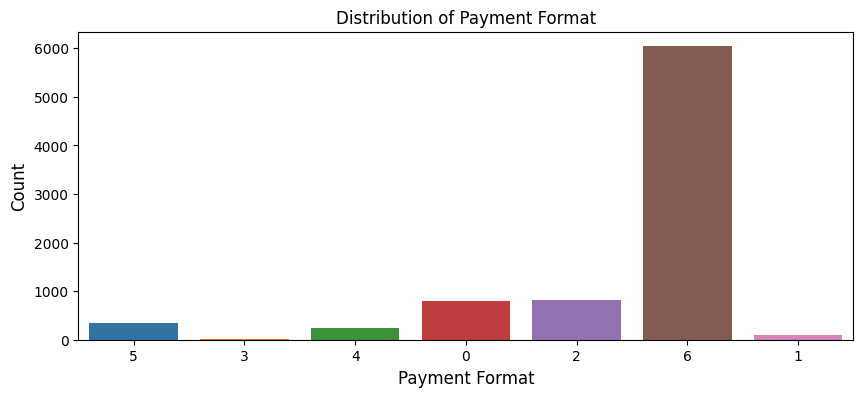

In [21]:
f, ax = plt.subplots(figsize=(10,4))

sns.countplot(x='Payment_Format', data=df, ax=ax)
ax.set_title('Distribution of Payment Format')
ax.set_xlabel('Payment Format', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

# Set the x-axis tick labels to the original values
ax.set_xticklabels(df['Payment_Format'].unique())

plt.show()

Distribution of the Is_Launderinges in the subsample dataset
Fraud
0    0.99988
1    0.00012
Name: count, dtype: float64


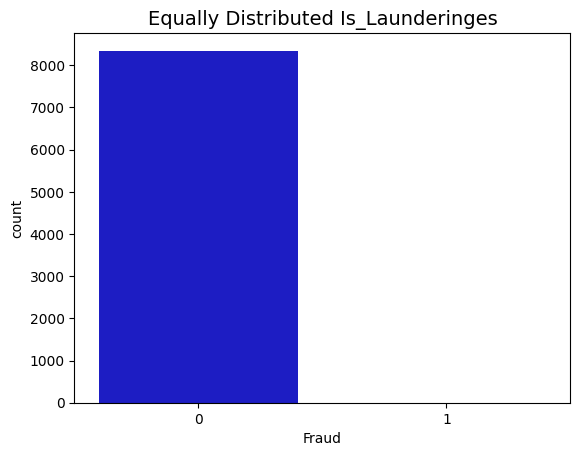

In [22]:
print('Distribution of the Is_Launderinges in the subsample dataset')
print(df['Fraud'].value_counts()/len(df))

colors = ["#0101DF", "#DF0101"]
sns.countplot(data=df, x='Fraud', palette=colors)
plt.title('Equally Distributed Is_Launderinges', fontsize=14)
plt.show()

In [23]:
from keras.layers import Input, Dense
from keras.models import Model
from keras.optimizers import Adam
from keras.layers import Dropout
from keras.layers import BatchNormalization
from keras.layers import Activation
from keras.layers import Concatenate
from keras.layers import AveragePooling1D
from keras.layers import GlobalMaxPooling1D
from keras.layers import GlobalAveragePooling1D
from keras.layers import Conv1D
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.nn as nn


2024-11-12 16:51:58.180923: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-12 16:51:58.181038: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-12 16:51:58.446940: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [24]:
import networkx as nx

In [25]:
"""Add edges and properties to the edges 
for _, row in df.iterrows():
    # Create a variable for each properties for each edge

        Fraud = row["Fraud"],
        Payment_Format = row["Payment_Format"],
        Payment_Currency = row["Payment_Currency"],
        Amount_Paid  = row["Amount_Paid"],
        Receiving_Currency =row["Receiving_Currency"],
        Amount_Received    = row["Amount_Received"],
        To_Bank =  row["To_Bank"],
        From_Bank = row["From_Bank"],
        date =  row["date"],
        time = row['time']
    
 
        G.add_edge(row['Sender'], row['Receiver'], Fraud = Fraud , Payment_Format = Payment_Format , Payment_Currency = Payment_Currency ,
              Amount_Paid = Amount_Paid , Receiving_Currency = Receiving_Currency , Amount_Received = Amount_Received , To_Bank = To_Bank ,
              From_Bank = From_Bank , date = date , time = time)
"""

'Add edges and properties to the edges \nfor _, row in df.iterrows():\n    # Create a variable for each properties for each edge\n\n        Fraud = row["Fraud"],\n        Payment_Format = row["Payment_Format"],\n        Payment_Currency = row["Payment_Currency"],\n        Amount_Paid  = row["Amount_Paid"],\n        Receiving_Currency =row["Receiving_Currency"],\n        Amount_Received    = row["Amount_Received"],\n        To_Bank =  row["To_Bank"],\n        From_Bank = row["From_Bank"],\n        date =  row["date"],\n        time = row[\'time\']\n    \n \n        G.add_edge(row[\'Sender\'], row[\'Receiver\'], Fraud = Fraud , Payment_Format = Payment_Format , Payment_Currency = Payment_Currency ,\n              Amount_Paid = Amount_Paid , Receiving_Currency = Receiving_Currency , Amount_Received = Amount_Received , To_Bank = To_Bank ,\n              From_Bank = From_Bank , date = date , time = time)\n'

In [26]:
# Create an empty graph
G = nx.MultiGraph()

for index, row in df.iterrows():
    G.add_edge(row['Sender'], row['Receiver'], 
               Amount_Paid=row['Amount_Paid'], Amount_Received=row['Amount_Received'], 
               Receiving_Currency=row['Receiving_Currency'], Payment_Currency=row['Payment_Currency'],
               From_Bank=row['From_Bank'], To_Bank=row['To_Bank'],Payment_Format = row["Payment_Format"])

# Node features
node_features = {
    'avg_transaction_amount': df.groupby('Sender')['Amount_Paid'].mean().fillna(0).to_dict(),
    'total_amount_received': df.groupby('Receiver')['Amount_Received'].sum().fillna(0).to_dict(),
    'total_amount_paid': df.groupby('Sender')['Amount_Paid'].sum().fillna(0).to_dict(),
    'frequency_of_transactions': df['Sender'].value_counts().to_dict(),
    'unique_receiving_currencies': df.groupby('Receiver')['Receiving_Currency'].nunique().to_dict(),
    'unique_paying_receiving': df.groupby('Sender')['Payment_Currency'].nunique().to_dict(),
    'unique_banks_used': df.groupby('Sender')[['From_Bank', 'To_Bank']].nunique().sum(axis=1).to_dict()
}

# Convert node features to a matrix
node_features_matrix = np.array([
    [node_features['avg_transaction_amount'].get(node, 0),
     node_features['total_amount_received'].get(node, 0),
     node_features['total_amount_paid'].get(node, 0),
     node_features['frequency_of_transactions'].get(node, 0),
     node_features['unique_receiving_currencies'].get(node, 0),
     node_features['unique_paying_receiving'].get(node, 0),
     node_features['unique_banks_used'].get(node, 0)]
    for node in G.nodes()
])

print("Node Features:")
print(node_features_matrix)


Node Features:
[[3.69734009e+03 3.69734009e+03 3.69734009e+03 ... 1.00000000e+00
  1.00000000e+00 2.00000000e+00]
 [9.99999978e-03 0.00000000e+00 9.99999978e-03 ... 0.00000000e+00
  1.00000000e+00 2.00000000e+00]
 [0.00000000e+00 9.99999978e-03 0.00000000e+00 ... 1.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [1.82905234e+05 1.82905234e+05 1.82905234e+05 ... 1.00000000e+00
  1.00000000e+00 2.00000000e+00]
 [1.43851300e+06 0.00000000e+00 2.87702600e+06 ... 0.00000000e+00
  1.00000000e+00 2.00000000e+00]
 [0.00000000e+00 2.87702600e+06 0.00000000e+00 ... 1.00000000e+00
  0.00000000e+00 0.00000000e+00]]


In [27]:

# Edge features
edge_features = {
    'total_amount_transferred': df.groupby(['Sender', 'Receiver']).agg(
        {'Amount_Paid': 'sum', 'Amount_Received': 'sum'}
    ).sum(axis=1).fillna(0).to_dict(),
    'common_receiving_currency': df.groupby(['Sender', 'Receiver'])['Receiving_Currency'].nunique().to_dict(),
    'common_payment_currency': df.groupby(['Sender', 'Receiver'])['Payment_Currency'].nunique().to_dict(),
    'common_banks_used': df.groupby(['Sender', 'Receiver'])[['From_Bank', 'To_Bank']].nunique().sum(axis=1).to_dict(),
    'common_payment_format': df.groupby(['Sender', 'Receiver'])['Payment_Format'].nunique().to_dict()
}

# Convert edge features to a matrix
edge_features_matrix = np.array([
    [edge_features['total_amount_transferred'].get((u, v), 0),
     edge_features['common_receiving_currency'].get((u, v), 0),
     edge_features['common_payment_currency'].get((u, v), 0),
     edge_features['common_banks_used'].get((u, v), 0),
     edge_features['common_payment_format'].get((u, v), 0)]
    
    for u, v in G.edges()
])

print("Edge Features:")
print(edge_features_matrix)

Edge Features:
[[7.39468018e+03 1.00000000e+00 1.00000000e+00 2.00000000e+00
  1.00000000e+00]
 [1.99999996e-02 1.00000000e+00 1.00000000e+00 2.00000000e+00
  1.00000000e+00]
 [2.93511406e+04 1.00000000e+00 1.00000000e+00 2.00000000e+00
  1.00000000e+00]
 ...
 [3.65810469e+05 1.00000000e+00 1.00000000e+00 2.00000000e+00
  1.00000000e+00]
 [5.75405200e+06 1.00000000e+00 1.00000000e+00 2.00000000e+00
  2.00000000e+00]
 [5.75405200e+06 1.00000000e+00 1.00000000e+00 2.00000000e+00
  2.00000000e+00]]


In [28]:
# Convert node features to tensor
node_features_tensor = torch.tensor(node_features_matrix, dtype=torch.float32)

# Labels
labels = torch.tensor(df['Fraud'].values, dtype=torch.float32).view(-1, 1)

# Align labels with node features
num_nodes = node_features_tensor.shape[0]
sliced_labels = labels[:num_nodes, :]

# Check if shapes match
if node_features_tensor.shape[0] == sliced_labels.shape[0]:
    print("Shapes Match!")
else:
    print("Shapes Still Mismatched :(")

Shapes Match!


In [29]:

sample_size = 5
for i, edge in enumerate(G.edges()):
    print(G.get_edge_data(*edge))
    if i >= sample_size - 1:
        break

{0: {'Amount_Paid': 3697.340087890625, 'Amount_Received': 3697.340087890625, 'Receiving_Currency': 12, 'Payment_Currency': 12, 'From_Bank': 10, 'To_Bank': 10, 'Payment_Format': 5}}
{0: {'Amount_Paid': 0.009999999776482582, 'Amount_Received': 0.009999999776482582, 'Receiving_Currency': 12, 'Payment_Currency': 12, 'From_Bank': 3208, 'To_Bank': 1, 'Payment_Format': 3}}
{0: {'Amount_Paid': 14675.5703125, 'Amount_Received': 14675.5703125, 'Receiving_Currency': 12, 'Payment_Currency': 12, 'From_Bank': 3209, 'To_Bank': 3209, 'Payment_Format': 5}}
{0: {'Amount_Paid': 2806.969970703125, 'Amount_Received': 2806.969970703125, 'Receiving_Currency': 12, 'Payment_Currency': 12, 'From_Bank': 12, 'To_Bank': 12, 'Payment_Format': 5}}
{0: {'Amount_Paid': 36682.96875, 'Amount_Received': 36682.96875, 'Receiving_Currency': 12, 'Payment_Currency': 12, 'From_Bank': 10, 'To_Bank': 10, 'Payment_Format': 5}}


In [30]:
# Prepare the data for input into the model
edge_list = list(G.edges(data=True))
list(edge_list[i][2].values())

[36682.96875, 36682.96875, 12, 12, 10, 10, 5]

In [31]:


# Define a simple GNN model
class GNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x


In [33]:
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.model_selection import train_test_split
# Initialize model, loss function, and optimizer
input_dim = node_features_matrix.shape[1]
hidden_dim = 64
output_dim = 1  # binary classification
model = GNN(input_dim, hidden_dim, output_dim)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


print("Node Features Shape:", node_features_tensor.shape)
print("Labels Shape:", sliced_labels.shape)
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(node_features_tensor, sliced_labels, test_size=0.2, random_state=42)

# Standardize node features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training loop
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(torch.tensor(X_train, dtype=torch.float32))
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# Evaluate the model on test set
with torch.no_grad():
    outputs = model(torch.tensor(X_test, dtype=torch.float32))
    predicted = (outputs > 0.5).float()
    accuracy = (predicted == y_test).float().mean()

# Evaluate the original model on the test set
    outputs_original = model(torch.tensor(X_test, dtype=torch.float32))
    predicted_original = (outputs_original > 0.5).float()
    
    # Convert tensors to numpy arrays
    y_test_np = y_test.numpy().flatten()
    predicted_original_np = predicted_original.numpy().flatten()
    
    # Compute accuracy
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test_np, predicted_original_np)
    print("Confusion Matrix:")
    print(cm)


    

Node Features Shape: torch.Size([6942, 7])
Labels Shape: torch.Size([6942, 1])
Epoch 1/100, Loss: 0.7523
Epoch 11/100, Loss: 0.6604
Epoch 21/100, Loss: 0.5812
Epoch 31/100, Loss: 0.5129
Epoch 41/100, Loss: 0.4535
Epoch 51/100, Loss: 0.4004
Epoch 61/100, Loss: 0.3519
Epoch 71/100, Loss: 0.3078
Epoch 81/100, Loss: 0.2678
Epoch 91/100, Loss: 0.2318
Confusion Matrix:
[[1389]]


In [38]:
# Define the FraudGNN model
class FraudGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(FraudGNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.dropout = nn.Dropout(0.5)  # Dropout layer for regularization
        self.fc2 = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        return x.squeeze(-1)

Epoch 1/100, Train Loss: 0.8560, Val Loss: 0.7259
Epoch 11/100, Train Loss: 0.7733, Val Loss: 0.7098
Epoch 21/100, Train Loss: 0.7450, Val Loss: 0.7045
Epoch 31/100, Train Loss: 0.7262, Val Loss: 0.7018
Epoch 41/100, Train Loss: 0.7167, Val Loss: 0.6999
Epoch 51/100, Train Loss: 0.7137, Val Loss: 0.6988
Epoch 61/100, Train Loss: 0.7086, Val Loss: 0.6979
Epoch 71/100, Train Loss: 0.7074, Val Loss: 0.6972
Epoch 81/100, Train Loss: 0.7046, Val Loss: 0.6966
Epoch 91/100, Train Loss: 0.7013, Val Loss: 0.6961


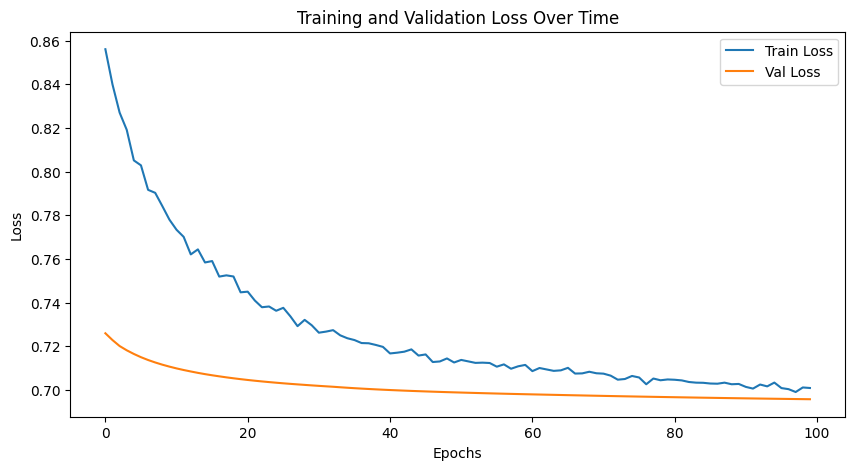

In [42]:
import matplotlib.pyplot as plt

# Split data into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(node_features_tensor, sliced_labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

input_dim = node_features_tensor.shape[1]  
hidden_dim = 64
model = FraudGNN(input_dim, hidden_dim)
criterion = nn.BCEWithLogitsLoss()  # Use logits for stability
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop with validation
train_losses = []
val_losses = []

epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    
    # Squeeze the target labels to match the output shape
    loss = criterion(outputs, y_train.squeeze(-1))
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # Validation
    model.eval()
    with torch.no_grad():
        outputs_val = model(X_val)
        
        # Squeeze the target labels for validation
        val_loss = criterion(outputs_val, y_val.squeeze(-1))
        val_losses.append(val_loss.item())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

    
    
# Plotting the losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.show()

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Define the Enhanced FraudGNN model
class EnhancedFraudGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(EnhancedFraudGNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        return x.squeeze(-1)



Epoch 1/100, Train Loss: 0.9011, Val Loss: 0.7518
Epoch 11/100, Train Loss: 0.7145, Val Loss: 0.7110
Epoch 21/100, Train Loss: 0.7023, Val Loss: 0.7010
Epoch 31/100, Train Loss: 0.6971, Val Loss: 0.6962
Epoch 41/100, Train Loss: 0.6949, Val Loss: 0.6943
Epoch 51/100, Train Loss: 0.6939, Val Loss: 0.6937
Epoch 61/100, Train Loss: 0.6936, Val Loss: 0.6934
Epoch 71/100, Train Loss: 0.6934, Val Loss: 0.6933
Epoch 81/100, Train Loss: 0.6933, Val Loss: 0.6932
Epoch 91/100, Train Loss: 0.6933, Val Loss: 0.6932


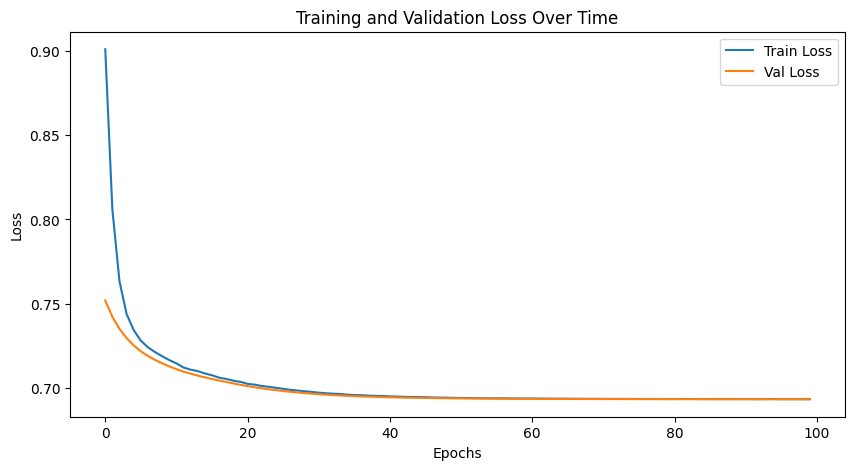

In [45]:
import matplotlib.pyplot as plt

# Split data into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(node_features_tensor, sliced_labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

input_dim = node_features_tensor.shape[1]  
hidden_dim = 64
model = EnhancedFraudGNN(input_dim, hidden_dim)
criterion = nn.BCEWithLogitsLoss()  # Use logits for stability
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop with validation
train_losses = []
val_losses = []

epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    
    # Squeeze the target labels to match the output shape
    loss = criterion(outputs, y_train.squeeze(-1))
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # Validation
    model.eval()
    with torch.no_grad():
        outputs_val = model(X_val)
        
        # Squeeze the target labels for validation
        val_loss = criterion(outputs_val, y_val.squeeze(-1))
        val_losses.append(val_loss.item())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

    
    
# Plotting the losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.show()